In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ALLFLOWMETER_HIKARI2021.csv')

In [ ]:
df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis = 1, inplace=True)

In [ ]:
df.shape

(555278, 86)

In [ ]:
df_exclude_object = df.select_dtypes(exclude=['object'])

In [ ]:
df_exclude_object['Label'].value_counts()

0    517582
1     37696
Name: Label, dtype: int64

In [ ]:
df_exclude_object.shape

(555278, 82)

In [ ]:
df_exclude_object.head(5)

,originp,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Label
0,13316,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,1
1,13318,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,...,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,1
2,13320,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,...,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,1
3,13322,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,...,123182.931318,9.759205e+06,9.759205e+06,9.759205e+06,9.759205e+06,0.0,29200,65160,0,1
4,13324,443,7.780611,14,14,6,5,1.799345,1.799345,3.598689,...,126016.885411,7.545305e+06,7.545305e+06,7.545305e+06,7.545305e+06,0.0,29200,65160,0,1


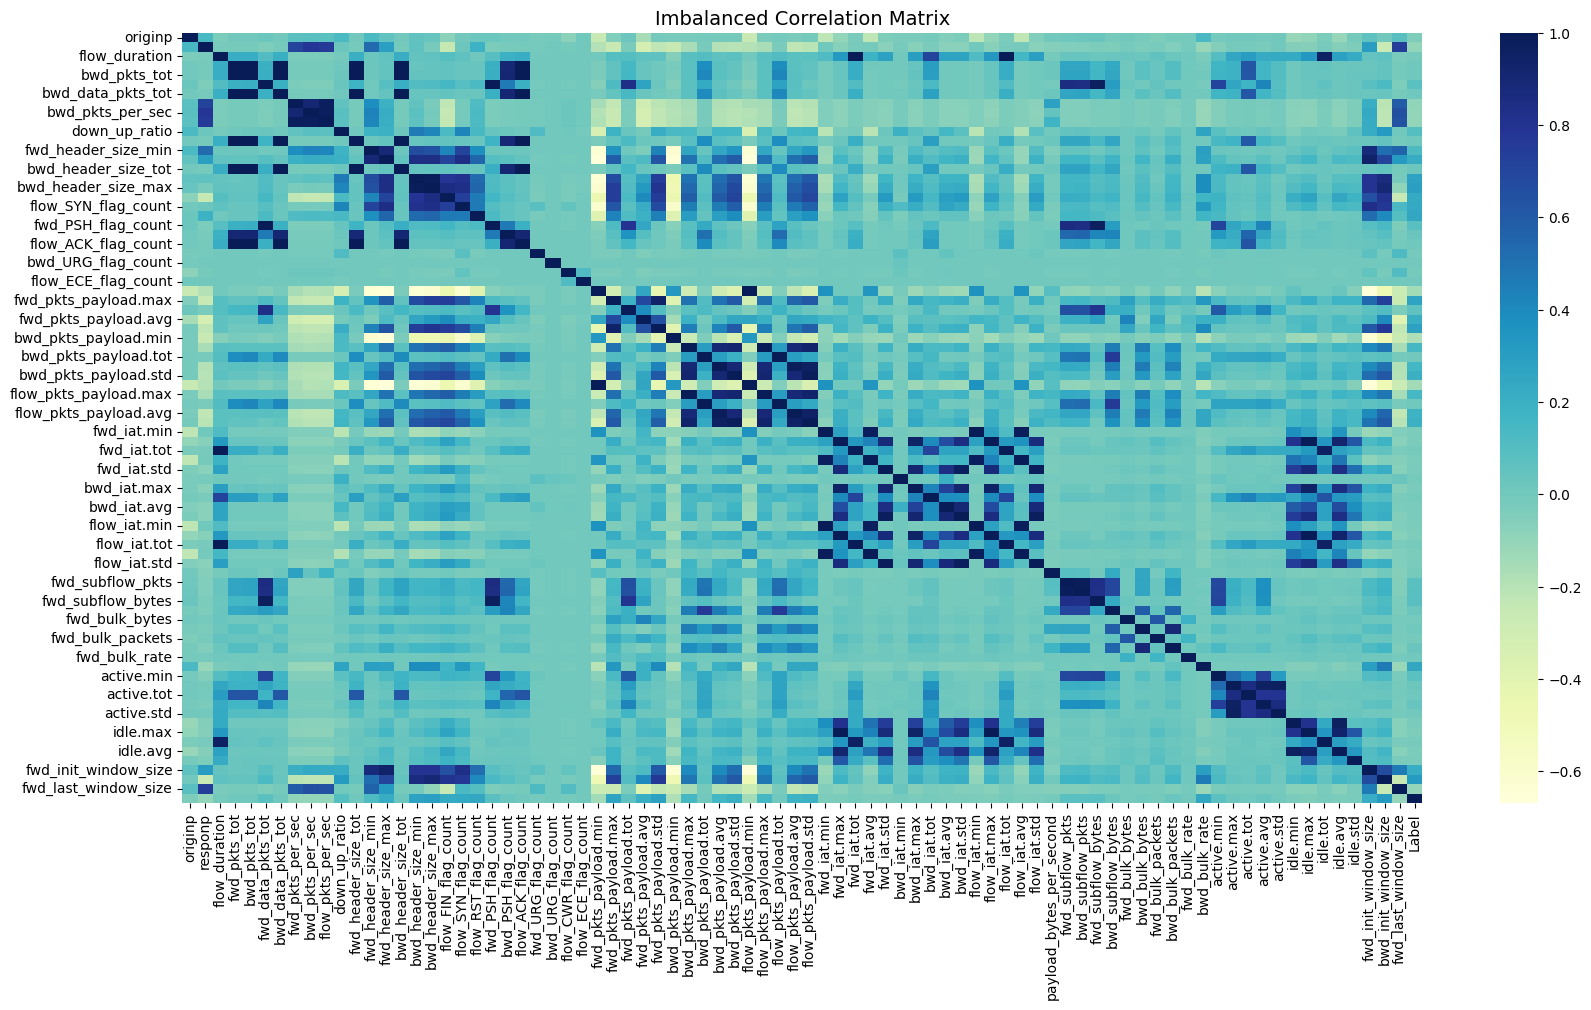

In [ ]:
# Sample figsize in inches
fig, ax = plt.subplots(figsize=(20,10))
# Imbalanced DataFrame Correlation
corr = df_exclude_object.corr()
sns.heatmap(corr, cmap='YlGnBu', annot_kws={'size':30}, ax=ax)
ax.set_title("Imbalanced Correlation Matrix", fontsize=14)
plt.show()

#StandardScaler
mengubah fitur menjadi single unit variance

In [ ]:
#pake PCA utk cari 2 principle components
from sklearn.preprocessing import StandardScaler

In [ ]:
#kita mau pastikan setiap feature kita itu hanya single unit variance
scaler = StandardScaler()
scaler.fit(df_exclude_object.iloc[:,:-1])

StandardScaler()

In [ ]:
scaled_data = scaler.transform(df_exclude_object.iloc[:,:-1])

#PCA
reduksi dimensi

##Menjadi 2 principal components

In [ ]:
#PCA
from sklearn.decomposition import PCA

In [ ]:
pca_2 = PCA(n_components = 2) #mencari 2 principle components

In [ ]:
pca_2.fit(scaled_data)

PCA(n_components=2)

In [ ]:
x_pca_2 = pca_2.transform(scaled_data)

In [ ]:
scaled_data.shape

(555278, 81)

In [ ]:
x_pca_2.shape

(555278, 2)

Text(0, 0.5, 'Second Principle Component')

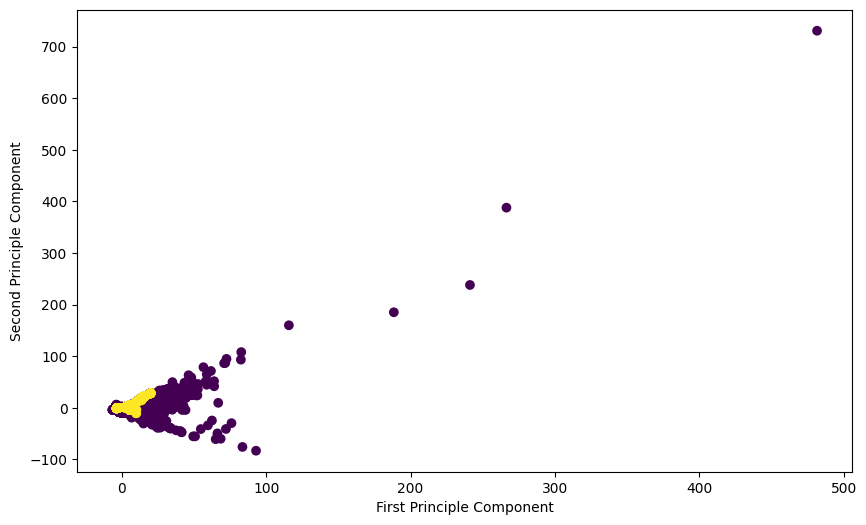

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(x_pca_2[:, 0], x_pca_2[:, 1], c=df['Label'], cmap = 'viridis')
plt.xlabel('First Principle Component')
plt.ylabel('Second Principle Component')

In [ ]:
pca_2.components_

array([[-2.06882830e-03, -2.89162141e-02,  8.56127608e-02,
         7.60491542e-02,  7.75979480e-02,  7.86609169e-02,
         7.49593829e-02, -3.31066134e-02, -3.36332110e-02,
        -3.41675775e-02,  6.29501178e-02,  7.51889218e-02,
         1.28439347e-01,  1.90032457e-01,  7.68849223e-02,
         1.91285361e-01,  2.04878455e-01,  2.07290809e-01,
         1.87699440e-01,  1.15126933e-01,  7.93558126e-02,
         9.24134591e-02,  7.69393909e-02, -2.80391426e-05,
        -3.59186346e-04, -3.31039194e-03, -6.68201990e-04,
        -1.22115226e-01,  1.84755177e-01,  7.12494766e-02,
         9.01419013e-02,  1.73962007e-01, -1.18180949e-01,
         1.84053420e-01,  9.25356005e-02,  1.81619701e-01,
         1.95962865e-01, -1.22107275e-01,  1.84119922e-01,
         9.56887544e-02,  1.86107393e-01,  1.98118349e-01,
        -9.68416329e-03,  1.35547704e-01,  8.52235372e-02,
         1.49958709e-02,  1.34780510e-01,  7.67207433e-04,
         1.45382549e-01,  1.05826196e-01,  1.17439353e-0

In [ ]:
df_comp = pd.DataFrame(pca_2.components_, columns=df_exclude_object.iloc[:,:-1].columns)

<Axes: >

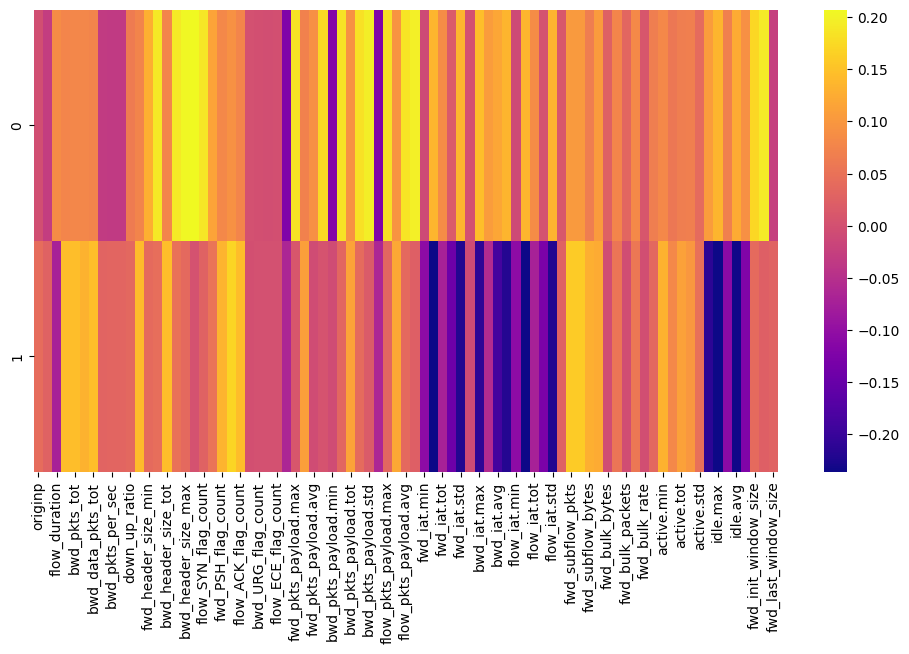

In [ ]:
plt.figure(figsize = (12,6))
sns.heatmap(df_comp, cmap='plasma')

Text(0, 0.5, 'Explained Variance')

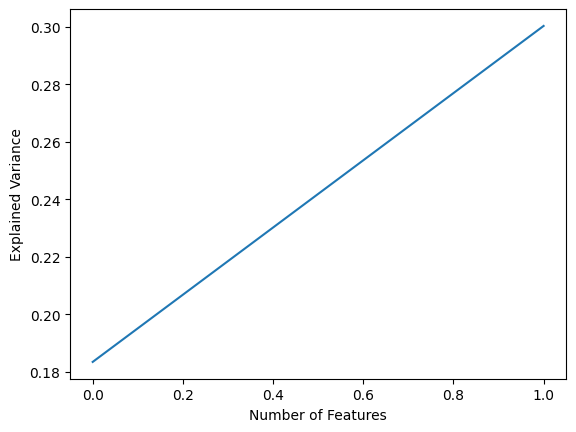

In [ ]:
# plot a scree plot
plt.plot(np.cumsum(pca_2.explained_variance_ratio_))
plt.xlabel('Number of Features')
plt.ylabel('Explained Variance')

##Menjadi 22 principal components
https://ieeexplore.ieee.org/abstract/document/9800807/

In [ ]:
pca = PCA(n_components = 22) #mencari 2 principle components

In [ ]:
pca.fit(scaled_data)

PCA(n_components=22)

In [ ]:
x_pca = pca.transform(scaled_data)

In [ ]:
scaled_data.shape

(555278, 81)

In [ ]:
x_pca.shape

(555278, 22)

In [ ]:
pca.components_

array([[-2.06882757e-03, -2.89162142e-02,  8.56127607e-02, ...,
         1.72039855e-01,  1.92802374e-01, -2.50856180e-02],
       [ 4.27887145e-02,  2.57979479e-02, -7.24512234e-02, ...,
         3.83373122e-02,  2.27215041e-02,  2.75104034e-02],
       [-3.83028264e-02, -3.78145385e-02,  1.45162339e-01, ...,
        -1.51934168e-01, -1.24503140e-01, -4.25007181e-02],
       ...,
       [-5.76205766e-02, -3.34522944e-02, -3.92829776e-03, ...,
        -2.15884709e-04,  1.96421557e-02, -2.17135561e-02],
       [ 2.11169709e-01,  9.13749002e-02, -4.76757202e-03, ...,
        -1.30893401e-02, -3.37785186e-02, -1.14841954e-02],
       [ 2.92017305e-01, -3.48063765e-02, -3.42830271e-03, ...,
         5.33458943e-02,  1.97449710e-03,  9.55838839e-02]])

In [ ]:
df_comp = pd.DataFrame(pca.components_, columns=df_exclude_object.iloc[:,:-1].columns)

<AxesSubplot:>

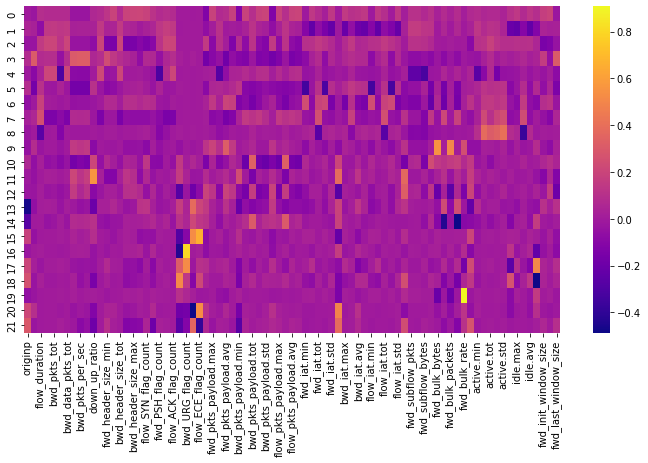

In [ ]:
plt.figure(figsize = (12,6))
sns.heatmap(df_comp, cmap='plasma')

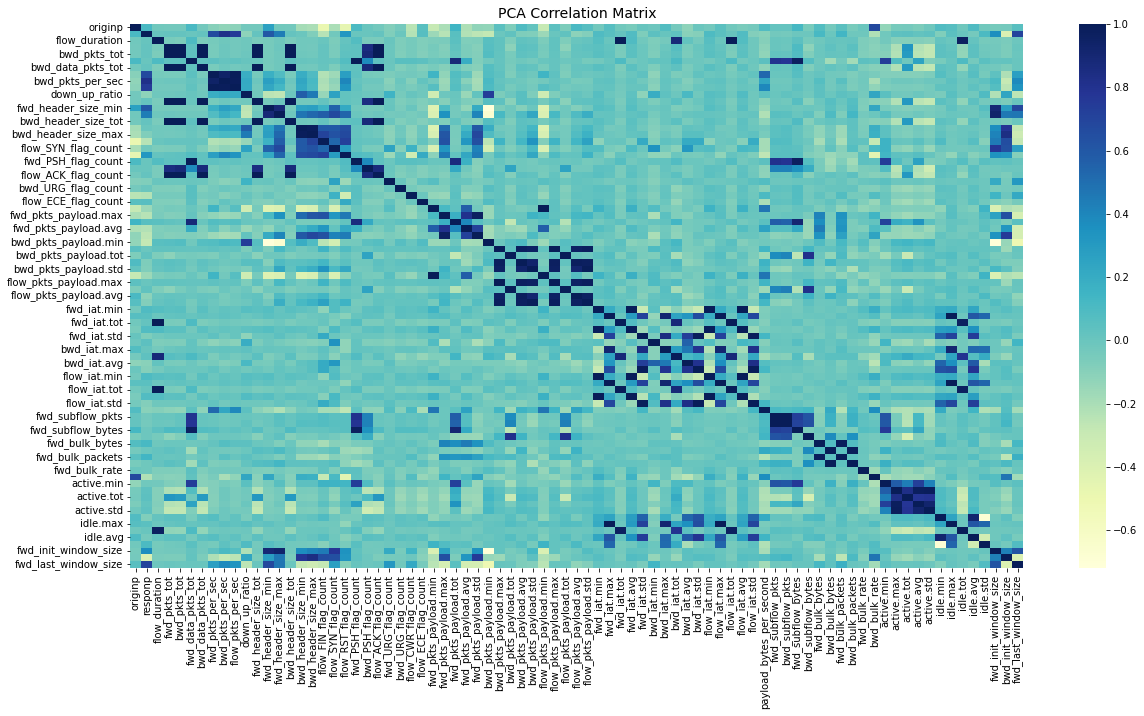

In [ ]:
# Sample figsize in inches
fig, ax = plt.subplots(figsize=(20,10))
# PCA DataFrame Correlation
corr = df_comp.corr()
sns.heatmap(corr, cmap='YlGnBu', annot_kws={'size':30}, ax=ax)
ax.set_title("PCA Correlation Matrix", fontsize=14)
plt.show()

Text(0, 0.5, 'Explained Variance')

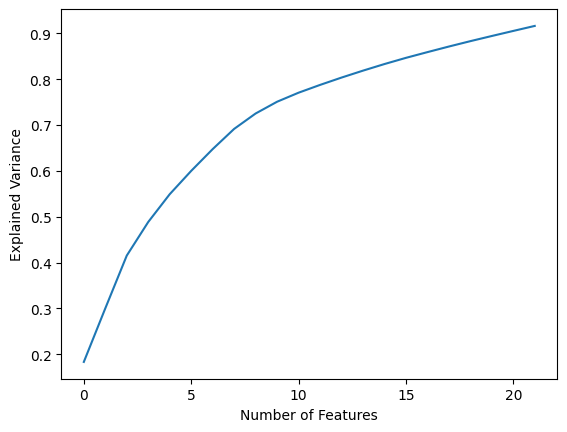

In [ ]:
# plot a scree plot
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Features')
plt.ylabel('Explained Variance')

#Classifications
memakai x_pca sebagai x_train kita

In [ ]:
from sklearn.model_selection import train_test_split
X = x_pca
y = df['Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

##Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=3000)

In [ ]:
logmodel.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [ ]:
predLR = logmodel.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, predLR))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97    155457
           1       0.04      0.00      0.00     11127

    accuracy                           0.93    166584
   macro avg       0.49      0.50      0.48    166584
weighted avg       0.87      0.93      0.90    166584



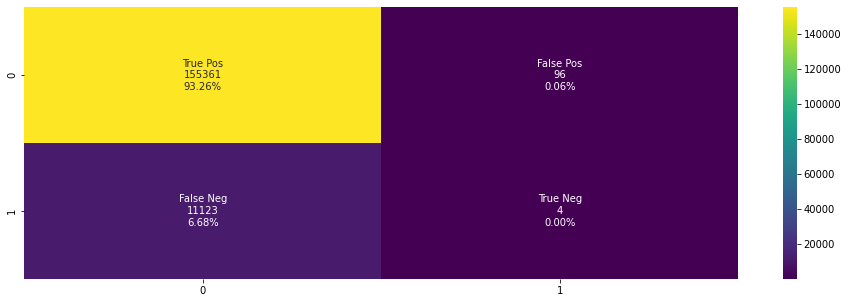

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predLR)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

##KNN Classifier
menggunakan n_neighbors default

In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
predKNN = knn.predict(X_test)

In [ ]:
print(classification_report(y_test, predKNN))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95    155457
           1       0.28      0.20      0.23     11127

    accuracy                           0.91    166584
   macro avg       0.61      0.58      0.59    166584
weighted avg       0.90      0.91      0.91    166584



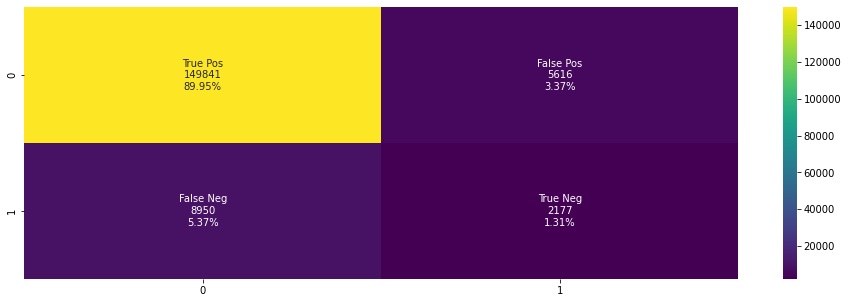

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predKNN)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

## Decision Tree dan Random Forest
max_depth default, n_estimators default

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dtree = DecisionTreeClassifier()

In [ ]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
predDtree = dtree.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print(classification_report(y_test, predDtree))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94    155457
           1       0.11      0.10      0.11     11127

    accuracy                           0.88    166584
   macro avg       0.52      0.52      0.52    166584
weighted avg       0.88      0.88      0.88    166584



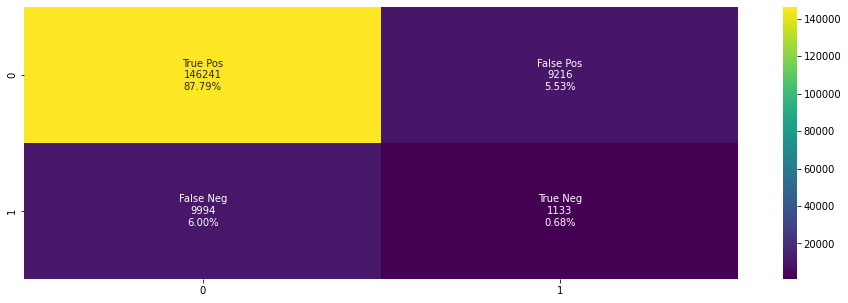

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predDtree)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier()

In [ ]:
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
predRFC = rfc.predict(X_test)

In [ ]:
print(classification_report(y_test, predRFC))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94    155457
           1       0.15      0.14      0.14     11127

    accuracy                           0.89    166584
   macro avg       0.54      0.54      0.54    166584
weighted avg       0.89      0.89      0.89    166584



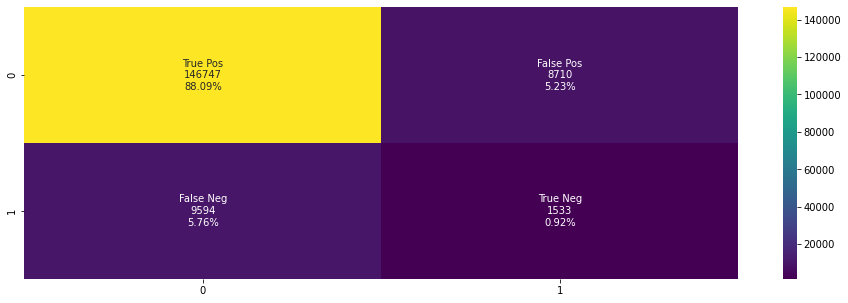

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predRFC)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

##Naive Bayes: Gaussian Classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Build a Gaussian Classifier
nbgc = GaussianNB()

In [ ]:
# Model training
nbgc.fit(X_train, y_train)

# Predict Output
predNBGC = nbgc.predict(X_test)

In [ ]:
print(classification_report(y_test, predNBGC))

              precision    recall  f1-score   support

           0       0.99      0.37      0.54    155457
           1       0.10      0.95      0.18     11127

    accuracy                           0.41    166584
   macro avg       0.54      0.66      0.36    166584
weighted avg       0.93      0.41      0.52    166584



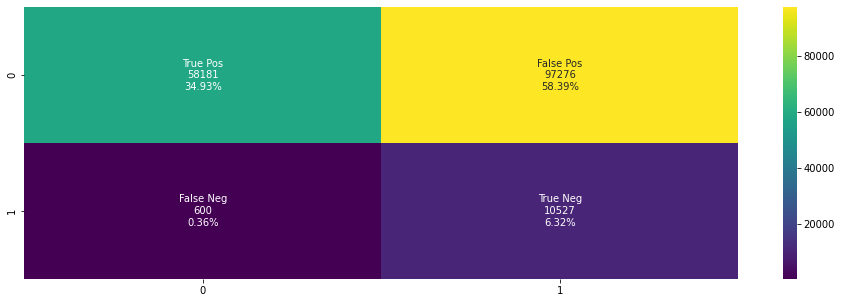

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, predNBGC)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');

##SVC

In [ ]:
from sklearn.svm import SVC

In [ ]:
svc = SVC()
'''
generalization:
low C = high bias, low variance
high C = low bias, low variance

low gamma = high variance
high gamma = low variance

gamma ada tergantung rbf
'''

'\ngeneralization:\nlow C = high bias, low variance\nhigh C = low bias, low variance\n\nlow gamma = high variance\nhigh gamma = low variance\n\ngamma ada tergantung rbf\n'

In [ ]:
svc.fit(X_train, y_train)

SVC()

In [ ]:
pred_svc = svc.predict(X_test)

In [ ]:
print(classification_report(y_test, pred_svc))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97    155457
           1       0.48      0.04      0.07     11127

    accuracy                           0.93    166584
   macro avg       0.71      0.52      0.52    166584
weighted avg       0.90      0.93      0.91    166584



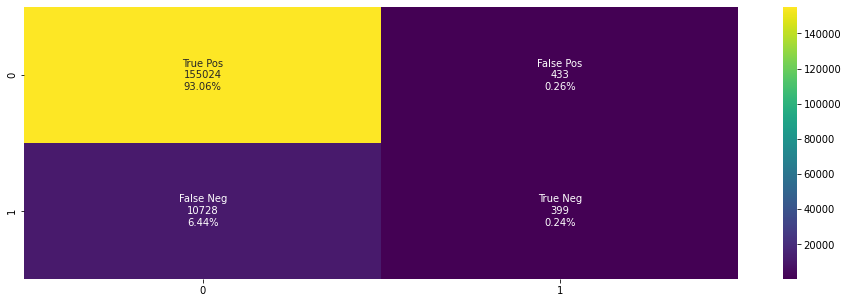

In [ ]:
# confusion matrix
group_names = ['True Pos', 'False Pos', 'False Neg', 'True Neg']
test_cnf_matrix = confusion_matrix(y_test, pred_svc)
test_counts = ["{0:0.0f}".format(value) for value in test_cnf_matrix.flatten()]
test_percentage = ["{0:.2%}".format(value) for value in test_cnf_matrix .flatten()/np.sum(test_cnf_matrix)]
test_labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,test_counts,test_percentage)]
test_labels = np.asarray(test_labels).reshape(2,2)
plt.figure(figsize = (16,5))
sns.heatmap(test_cnf_matrix, annot=test_labels, fmt='', cmap='viridis');